# 02 - Baseline : Single Quantum Kernel

Ce notebook établit les baselines avec un seul quantum kernel avant
de passer au Multiple Kernel Learning.

**Objectifs :**
- Tester différentes feature maps individuellement
- Mesurer l'impact du bandwidth α
- Observer la concentration exponentielle

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
from sklearn.model_selection import train_test_split

from data.loaders import load_dataset
from src.preprocessing import QuantumScaler, FeatureReducer
from src.kernels import build_feature_map, build_quantum_kernel, compute_kernel_matrix
from src.kernels.kernel_matrix import kernel_statistics
from src.models import QSVM
from src.evaluation import compute_all_metrics
from src.evaluation.visualization import plot_kernel_heatmap, plot_roc_curve

%matplotlib inline

## 1. Préparation des données

In [2]:
# Charger et préprocesser
X, y = load_dataset('german_credit', n_samples=400, random_state=42)

n_qubits = 6  # Commencer petit pour rapidité
reducer = FeatureReducer(n_components=n_qubits)
scaler = QuantumScaler(feature_range=(0, 2))

X_reduced = reducer.fit_transform(X)
X_scaled = scaler.fit_transform(X_reduced)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.33, random_state=42, stratify=y
)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

/Users/raph/Desktop/Academic/Projet infoQ/Projet-QMKL-Finance/.venv/lib/python3.9/site-packages/sklearn/datasets/_openml.py:75: RuntimeWarning: Invalid cache, redownloading file
  warn("Invalid cache, redownloading file", RuntimeWarning)


Train: (268, 6), Test: (132, 6)


## 2. Test de différentes feature maps

In [3]:
configs = [
    ('Z (α=2)',   'Z',  2.0, 1),
    ('ZZ (α=2)',  'ZZ', 2.0, 1),
    ('ZZ (α=20)', 'ZZ', 20.0, 1),
    ('Pauli (α=0.6)', 'pauli', 0.6, 2),
]

results = {}
for label, name, alpha, reps in configs:
    print(f'\nComputing kernel: {label}...')
    fm = build_feature_map(name, n_qubits, alpha=alpha, reps=reps)
    qk = build_quantum_kernel(fm, kernel_type='fidelity')
    
    K_train = compute_kernel_matrix(qk, X_train)
    K_test = compute_kernel_matrix(qk, X_train, X_test)
    
    # Statistiques du kernel
    stats = kernel_statistics(K_train)
    print(f'  Mean: {stats["mean"]:.4f}, Var: {stats["variance"]:.6f}')
    
    # Train QSVM
    svm = QSVM(C=1.0)
    svm.fit(K_train, y_train)
    
    y_pred = svm.predict(K_test)
    y_proba = svm.predict_proba(K_test)
    
    metrics = compute_all_metrics(y_test, y_pred, y_proba)
    results[label] = metrics
    print(f'  ROC-AUC: {metrics.get("roc_auc", "N/A"):.4f}, Accuracy: {metrics["accuracy"]:.4f}')


Computing kernel: Z (α=2)...
  Mean: 0.0472, Var: 0.012761
  ROC-AUC: 0.6959, Accuracy: 0.7273

Computing kernel: ZZ (α=2)...
  Mean: 0.0167, Var: 0.002097
  ROC-AUC: 0.7155, Accuracy: 0.7576

Computing kernel: ZZ (α=20)...
  Mean: 0.0168, Var: 0.001892
  ROC-AUC: 0.7356, Accuracy: 0.7500

Computing kernel: Pauli (α=0.6)...
  Mean: 0.0462, Var: 0.008779
  ROC-AUC: 0.7269, Accuracy: 0.7652


## 3. Visualisation des kernels

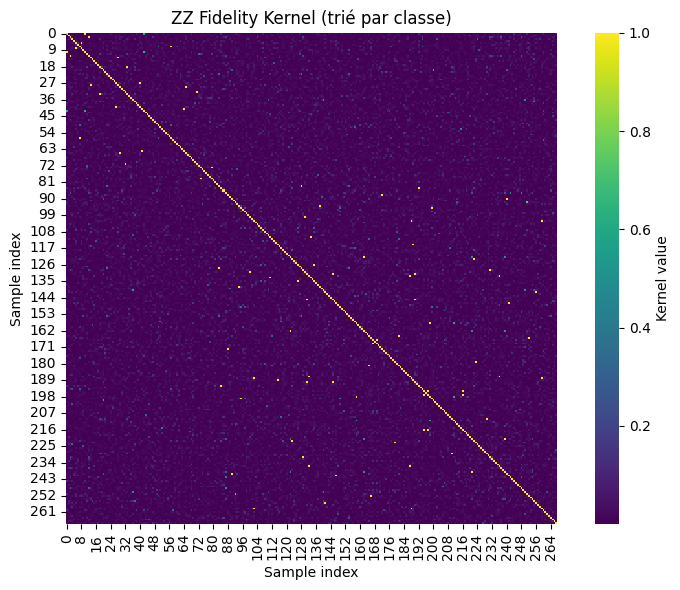

In [4]:
# Visualiser le meilleur kernel
fm = build_feature_map('ZZ', n_qubits, alpha=2.0, reps=1)
qk = build_quantum_kernel(fm, kernel_type='fidelity')
K = compute_kernel_matrix(qk, X_train)

# Trier par label pour voir la structure
sort_idx = np.argsort(y_train)
K_sorted = K[np.ix_(sort_idx, sort_idx)]
plot_kernel_heatmap(K_sorted, title='ZZ Fidelity Kernel (trié par classe)')

## 4. Étude de la concentration exponentielle

Computing kernel for dim=4...
Computing kernel for dim=6...
Computing kernel for dim=8...
Computing kernel for dim=10...
Computing kernel for dim=12...


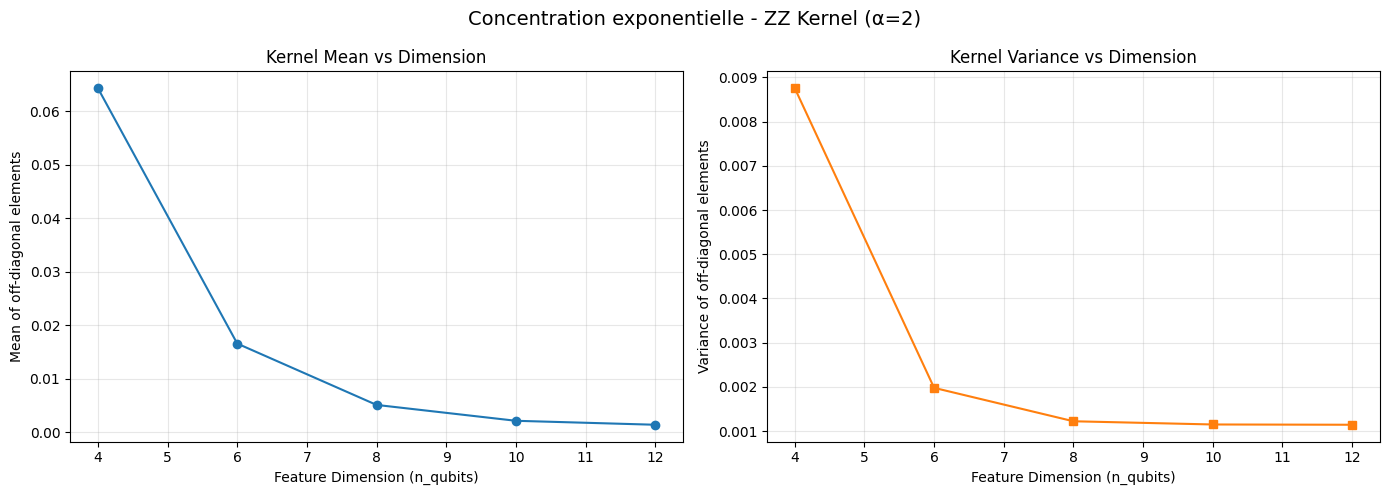

: 

In [ ]:
from src.evaluation.visualization import plot_concentration

dims = [4, 6, 8, 10, 12]
stats_by_dim = {}

for d in dims:
    print(f'Computing kernel for dim={d}...')
    red = FeatureReducer(n_components=d)
    sc = QuantumScaler(feature_range=(0, 2))
    X_d = sc.fit_transform(red.fit_transform(X))
    
    X_tr, _, y_tr, _ = train_test_split(X_d, y, test_size=0.33, random_state=42)
    
    fm = build_feature_map('ZZ', d, alpha=2.0, reps=1)
    qk = build_quantum_kernel(fm, kernel_type='fidelity')
    K = compute_kernel_matrix(qk, X_tr)
    stats_by_dim[d] = kernel_statistics(K)

plot_concentration(stats_by_dim, title='Concentration exponentielle - ZZ Kernel (α=2)')